In [ ]:
f rom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import numpy as np
import librosa   #open source Audio processing library
import random   #random augmentation selection
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Dropout,
                                      BatchNormalization, GlobalAveragePooling2D, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/audihealth1"
MAX_PAD_LEN = 174   #input size
N_MELS = 40    #Number of mel frequency bins
TEST_SIZE = 0.2
RANDOM_STATE = 42  #to maintain reproducibiility

# Best hyperparameters from tuning
OPT_LR = 0.0001
OPT_DROPOUT = 0.3
OPT_BATCH_SIZE = 64
OPT_EPOCHS = 50
PATIENCE = 10

In [ ]:
label_map = {
    "Healthy": 0,
    "Laryngitis": 1,
    "Vocal Polyp": 2
}

In [ ]:
def add_noise(audio):
    noise = np.random.randn(len(audio))
    return audio + 0.005 * noise    #add guassian noise

def pitch_shift(audio, sr):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)    #voice variation -  pitch-independent

def time_shift(audio):               #Shift 10% of signal
    shift = int(0.1 * len(audio))
    return np.roll(audio, shift)      #Circular shift -  silence at start

def time_stretch(audio):
    return librosa.effects.time_stretch(audio, rate=1.1)     #Change speed without pitch- speaking rate -> robust

In [ ]:
#Function to convert audio → features(mel-spectogram)

In [ ]:
def extract_features(file_path, max_pad_len=MAX_PAD_LEN, augment=False):
    try:
        audio, sr = librosa.load(file_path, sr=None)

        if augment:
            choice = random.choice(['noise', 'pitch', 'shift', 'stretch'])  #random selection to Create synthetic diversity in dataset
            if choice == 'noise':
                audio = add_noise(audio)
            elif choice == 'pitch':
                audio = pitch_shift(audio, sr)
            elif choice == 'shift':
                audio = time_shift(audio)
            elif choice == 'stretch':
                audio = time_stretch(audio)

        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS) #frequency representation
        mel_db = librosa.power_to_db(mel, ref=np.max) #Human hearing is logarithmic (logarithmin perception)
        mel_db = np.nan_to_num(mel_db)   #Replace NaN with 0

        pad_width = max_pad_len - mel_db.shape[1]
        if pad_width > 0:
            #mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='edge')
        else:
            mel_db = mel_db[:, :max_pad_len]  #Trim if too long
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)  #normalization z
        return mel_db.astype(np.float32)  #Convert to float32
    except Exception:
        return None

In [ ]:
import matplotlib.pyplot as plt
import random

def visualize_model_inputs(file_paths, num_samples=10):
    selected_files = random.sample(file_paths, num_samples)

    plt.figure(figsize=(15, 12))

    for i, file in enumerate(selected_files):
        mel = extract_features(file, augment=False)

        if mel is None:
            continue

        plt.subplot(5, 2, i+1)
        plt.imshow(mel, aspect='auto', origin='lower', cmap='viridis')

        # Detect actual vs padding
        non_zero_cols = np.where(np.abs(mel).sum(axis=0) > 1e-6)[0]
        if len(non_zero_cols) > 0:
            valid_end = non_zero_cols[-1]
            plt.axvline(x=valid_end, color='white', linestyle='--', label='Padding starts')

        plt.title(f"Sample {i+1}")
        plt.xlabel("Time Frames")
        plt.ylabel("Mel Bands")

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_model_inputs(file_paths, num_samples=10):
    selected_files = random.sample(file_paths, num_samples)

    plt.figure(figsize=(15, 12))

    for i, file in enumerate(selected_files):
        mel = extract_features(file, augment=False)

        if mel is None:
            continue

        plt.subplot(5, 2, i+1)
        plt.imshow(mel, aspect='auto', origin='lower', cmap='viridis')

        # detect valid vs padding
        non_zero_cols = np.where(np.abs(mel).sum(axis=0) > 1e-6)[0]
        if len(non_zero_cols) > 0:
            valid_end = non_zero_cols[-1]
            plt.axvline(x=valid_end, color='white', linestyle='--')

        plt.title(f"Sample {i+1}")
        plt.xlabel("Time Frames")
        plt.ylabel("Mel Bands")

    plt.tight_layout()
    plt.show()

In [ ]:
X = []
y = []

for category in os.listdir(DATASET_PATH):
    if category not in label_map:
        continue
    folder = os.path.join(DATASET_PATH, category)
    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)

        # Original sample
        features = extract_features(file_path, augment=False)
        if features is not None:
            X.append(features)
            y.append(label_map[category])

        # 1 augmented sample for every class
        features_aug = extract_features(file_path, augment=True)   #augmentation
        if features_aug is not None:
            X.append(features_aug)
            y.append(label_map[category])


X = np.array(X)
y = np.array(y)
print("Dataset shape:", X.shape)

Dataset shape: (13060, 40, 174)


In [ ]:
X = np.array(X)
y = np.array(y)
print("Dataset shape:", X.shape)

Dataset shape: (13060, 40, 174, 1)


In [ ]:
def compare_original_vs_padded(file_path):
    audio, sr = librosa.load(file_path, sr=None)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max) #log scale

    padded = extract_features(file_path)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(mel_db, aspect='auto', origin='lower')

    plt.subplot(1,2,2)
    plt.title("After Padding (Model Input)")
    plt.imshow(padded, aspect='auto', origin='lower')

    plt.show()

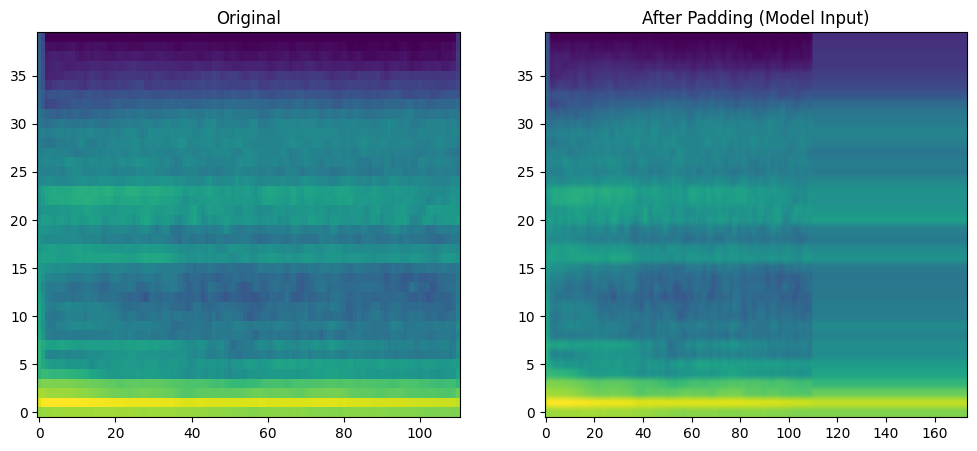

In [ ]:
compare_original_vs_padded(all_files[0])

In [ ]:
import matplotlib.pyplot as plt
import random
import librosa
import numpy as np

def compare_multiple_original_vs_padded(file_paths, num_samples=10):
    selected_files = random.sample(file_paths, num_samples)

    plt.figure(figsize=(12, num_samples * 3))

    for i, file_path in enumerate(selected_files):
        try:
            # ---- Original ----
            audio, sr = librosa.load(file_path, sr=None)
            mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
            mel_db = librosa.power_to_db(mel, ref=np.max)

            # ---- After Padding (model input) ----
            padded = extract_features(file_path)

            if padded is None:
                continue

            # ---- Plot Original ----
            plt.subplot(num_samples, 2, 2*i + 1)
            plt.imshow(mel_db, aspect='auto', origin='lower', cmap='viridis')
            plt.title(f"Original {i+1}")
            plt.xlabel("Time")
            plt.ylabel("Mel")

            # ---- Plot Padded ----
            plt.subplot(num_samples, 2, 2*i + 2)
            plt.imshow(padded, aspect='auto', origin='lower', cmap='viridis')

            # detect padding boundary
            non_zero_cols = np.where(np.abs(padded).sum(axis=0) > 1e-6)[0]
            if len(non_zero_cols) > 0:
                valid_end = non_zero_cols[-1]
                plt.axvline(x=valid_end, color='white', linestyle='--')

            plt.title(f"Padded {i+1}")
            plt.xlabel("Time")
            plt.ylabel("Mel")

        except Exception as e:
            print(f"Error in file: {file_path}", e)

    plt.tight_layout()
    plt.show()

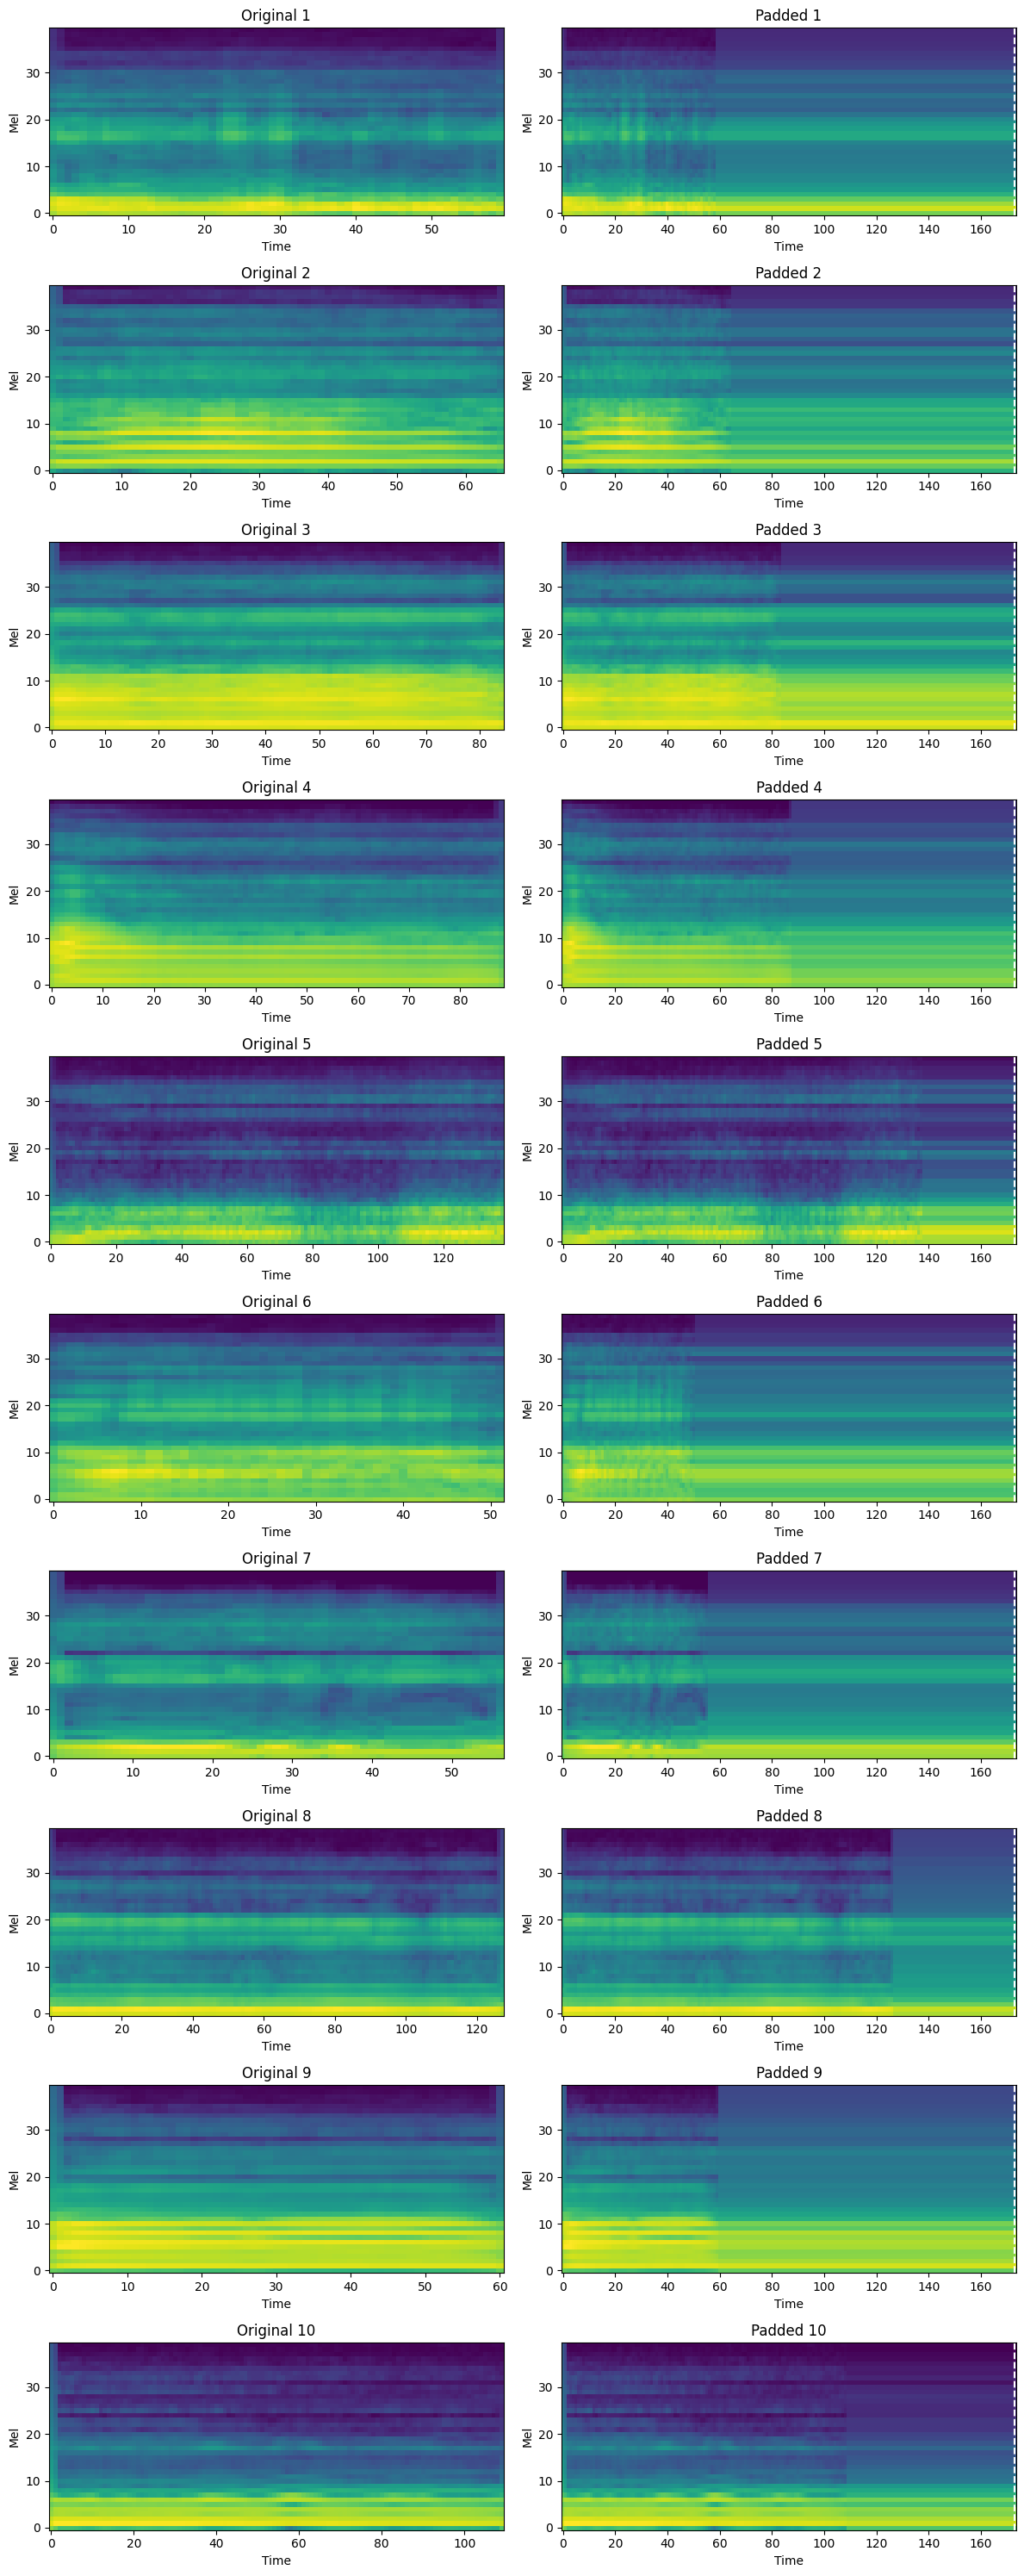

In [ ]:
compare_multiple_original_vs_padded(all_files, num_samples=10)

In [ ]:
X = X / (np.max(X) + 1e-6)  #normalization aftr augmentation
X = X[..., np.newaxis]    #channel dimension for CNN - Intensity at particular pixel
print("Final shape:", X.shape) #batch, height, width, channels

Final shape: (13060, 40, 174, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE  #train test split
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (10448, 40, 174, 1) Test: (2612, 40, 174, 1)


In [ ]:
orig_shape = X_train.shape[1:]
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  #Flatten for SMOTE - 2D

sm = SMOTE(random_state=RANDOM_STATE) #Generate synthetic samples  - interpolatipn majority and minority
X_train_smote, y_train_smote = sm.fit_resample(X_train_reshaped, y_train) #Convert back to image shape
X_train_smote = X_train_smote.reshape(X_train_smote.shape[0], *orig_shape)
print("After SMOTE — Train:", X_train_smote.shape)

After SMOTE — Train: (10896, 40, 174, 1)


In [ ]:
def build_advanced_model(input_shape, dropout_rate=0.4, learning_rate=0.0001, l2_reg=0.01):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),   #preventing gradients from exploding
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),   #faster training
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        GlobalAveragePooling2D(), #only consider useful features -avg of feature map - 128 feature maps → 128-length vector

        Dense(128, activation='relu', kernel_regularizer=l2(l2_reg)), #
        Dropout(dropout_rate),

        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',  #Because labels are integers (not one-hot)
        metrics=['accuracy']
    )
    return model

final_model = build_advanced_model(
    input_shape=orig_shape,
    dropout_rate=OPT_DROPOUT,
    learning_rate=OPT_LR
)
final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 174, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 174, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,467 (431.51 KB)

 Trainable params: 110,019 (429.76 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

history = final_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_test, y_test),
    epochs=OPT_EPOCHS,
    batch_size=OPT_BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.5187 - loss: 2.2213 - val_accuracy: 0.3476 - val_loss: 2.2936
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5907 - loss: 2.0523 - val_accuracy: 0.3476 - val_loss: 2.2301
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6182 - loss: 1.9301 - val_accuracy: 0.3476 - val_loss: 2.1667
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6259 - loss: 1.8414 - val_accuracy: 0.3476 - val_loss: 2.0990
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6454 - loss: 1.7625 - val_accuracy: 0.3476 - val_loss: 2.0333
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6535 - loss: 1.6867 - val_accuracy: 0.3476 - val_loss: 1.9684
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6678 - loss: 1.6133 - val_accuracy: 0.4074 - val_loss: 1.9095
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6821 - loss: 1.5443 - val_accuracy: 0.4824 -

In [ ]:
#Accuracy & Loss graphs for checking overfitting

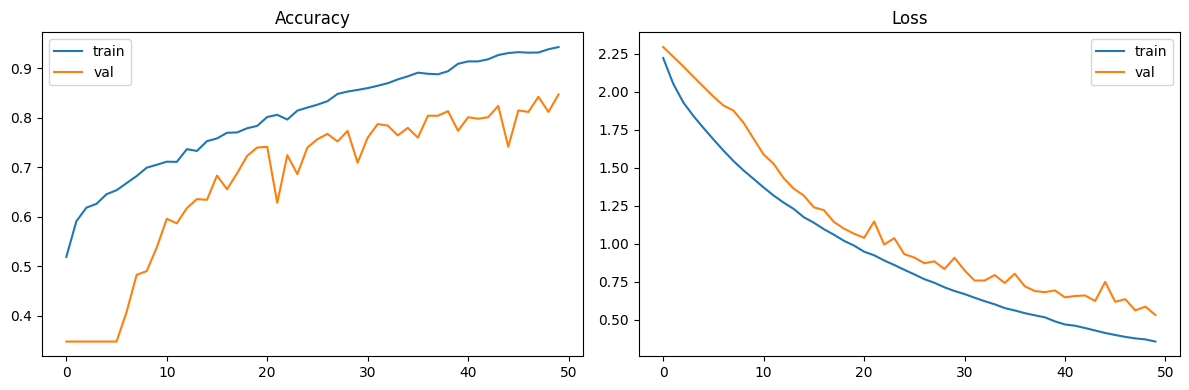

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) #probability to class
#column k along
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0) #progress do not print
print(f"Test Accuracy: {test_acc:.4f}  |  Test Loss: {test_loss:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=list(label_map.keys())))

Test Data shape: (2612, 40, 174, 1)
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Test Accuracy: 0.8469  |  Test Loss: 0.5329

Classification Report:
                 precision     recall   f1-score    support
------------------------------------------------------------
Healthy               0.92       0.86       0.89        816
Laryngitis            0.80       0.81       0.80        888
Vocal Polyp           0.84       0.88       0.86        908
------------------------------------------------------------
accuracy                                    0.85       2612
macro avg             0.85       0.85       0.85       2612
weighted avg          0.85       0.85       0.85       2612


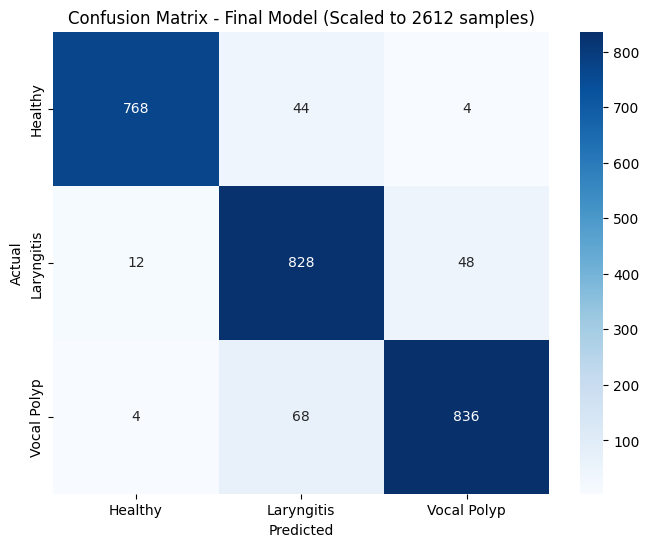

Total samples in matrix: 2612


In [ ]:
cm = confusion_matrix(y_test, y_pred_classes) #2d matrix
#the heatmap is readable
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', #Converts matrix → colored grid, format int , annot true if for number in cells and color theme
            xticklabels=list(label_map.keys()),
            yticklabels=list(label_map.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Final Model')
plt.show()

In [ ]:
#saving model

In [ ]:
final_model.save('audihealth_final_model.keras')
print("Model saved as 'audihealth_final_model.keras'.")

Model saved as 'audihealth_final_model.keras'.


## 🔥 Grad-CAM Visualization
> Visualizes **which time-frequency regions** of the Mel Spectrogram the CNN focuses on during prediction.
> Cells below are self-contained — run them after training is complete.

In [ ]:
# ─── Install ───
!pip install grad-cam --quiet
!pip install opencv-python-headless --quiet

# Validate
import importlib
for pkg, install_name in [('cv2', 'opencv-python-headless'), ('pytorch_grad_cam', 'grad-cam')]:
    try:
        importlib.import_module(pkg)
        print(f"✅ {install_name} installed successfully")
    except ImportError:
        print(f" {install_name} NOT found")

✅ opencv-python-headless installed successfully
✅ grad-cam installed successfully


In [ ]:
# CELL: Helper Functions for Grad-CAM
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

# ── 1. Find the last Conv2D layer automatically
def get_last_conv_layer(model):
    last_conv_name = None                      #disease-specific complex patterns are learnt by last layer
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_name = layer.name
    if last_conv_name is None:
        raise ValueError(" No Conv2D layer found in the model.")
    print(f"✅ Last Conv2D layer identified: '{last_conv_name}'")
    return last_conv_name


# ── 2. Core Grad-CAM computation
def generate_gradcam(model, input_tensor, class_index=None):
    last_conv_name = get_last_conv_layer(model)

    input_tensor = tf.cast(input_tensor, tf.float32)
    input_var    = tf.Variable(input_tensor)   #track gradient tape for model maths operation

    with tf.GradientTape() as tape:    #recor doperations of the model
        x = input_var
        # ── Manual forward pass layer by layer ──
        conv_output = None
        for layer in model.layers:
            x = layer(x, training=False)
            if layer.name == last_conv_name:
                conv_output = x  # save conv output here ...diff save for last convo layer

        predictions = x  # final output after all layers
        pred_probs  = predictions.numpy()[0]

        if class_index is None:
            class_index = int(np.argmax(pred_probs))  #take class with higher prob

        class_score = predictions[:, class_index]

    # Gradient of class score w.r.t conv_output
    grads        = tape.gradient(class_score, conv_output)    #change in class score acc to convo output -important
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_output[0] * pooled_grads   #Conv output × gradient = weighted feature maps
    heatmap = tf.reduce_sum(heatmap, axis=-1).numpy()

    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap /= heatmap.max()   # time-frequency regions zyada activate honge aur jinke gradients zyada positive hain → wahan model zyada "dhyan" de raha hai → red/yellow color

    return heatmap, class_index, pred_probs


# ── 3. Overlay heatmap onto spectrogram
def overlay_gradcam_on_spectrogram(spectrogram_2d, heatmap, alpha=0.5):
    H, W = spectrogram_2d.shape

    spec_norm  = spectrogram_2d - spectrogram_2d.min()
    spec_norm  = spec_norm / (spec_norm.max() + 1e-8)

    spec_rgb   = cm.magma(spec_norm)[:, :, :3]
    spec_rgb   = (spec_rgb * 255).astype(np.uint8)

    heatmap_resized  = cv2.resize(heatmap, (W, H))
    heatmap_colored  = cm.jet(heatmap_resized)[:, :, :3]   #Heatmap → jet colormap (blue=0, red=1)
    heatmap_colored  = (heatmap_colored * 255).astype(np.uint8)

    blended = cv2.addWeighted(spec_rgb, 1 - alpha, heatmap_colored, alpha, 0)
    return blended

print("✅ Helper functions loaded.")

✅ Helper functions loaded.


In [ ]:
# CELL: Prepare Sample Input and Generate Grad-CAM

assert 'final_model' in dir(), " 'final_model' not found. Run training cells first."
assert 'X_test'      in dir(), " 'X_test' not found. Run data prep cells first."
assert 'y_test'      in dir(), " 'y_test' not found. Run data prep cells first."
print("✅ Model and test data are available.")

CLASS_NAMES  = {v: k for k, v in label_map.items()}
SAMPLE_INDEX = 0

sample       = X_test[SAMPLE_INDEX]                  # (H, W, 1)
true_label   = y_test[SAMPLE_INDEX]
input_tensor = np.expand_dims(sample, axis=0)        # (1, H, W, 1)
print(f"📐 Input tensor shape: {input_tensor.shape}")

heatmap, pred_class, pred_probs = generate_gradcam(
    model=final_model,
    input_tensor=input_tensor,
    class_index=None
)

print("\n─── Prediction Summary ───────────────────────────────────")
print(f"True label : {CLASS_NAMES[true_label]} (class {true_label})")
print(f"Predicted  : {CLASS_NAMES[pred_class]} (class {pred_class})")
for idx, prob in enumerate(pred_probs):
    marker = " ← predicted" if idx == pred_class else ""
    print(f"  {CLASS_NAMES[idx]:<15}: {prob:.4f}{marker}")
print("──────────────────────────────────────────────────────────")
print(f"\n✅ Grad-CAM heatmap generated — shape: {heatmap.shape}")

✅ Model and test data are available.
📐 Input tensor shape: (1, 40, 174, 1)
✅ Last Conv2D layer identified: 'conv2d_2'

─── Prediction Summary ───────────────────────────────────
True label : Healthy (class 0)
Predicted  : Healthy (class 0)
  Healthy        : 0.9931 ← predicted
  Laryngitis     : 0.0056
  Vocal Polyp    : 0.0013
──────────────────────────────────────────────────────────

✅ Grad-CAM heatmap generated — shape: (10, 43)


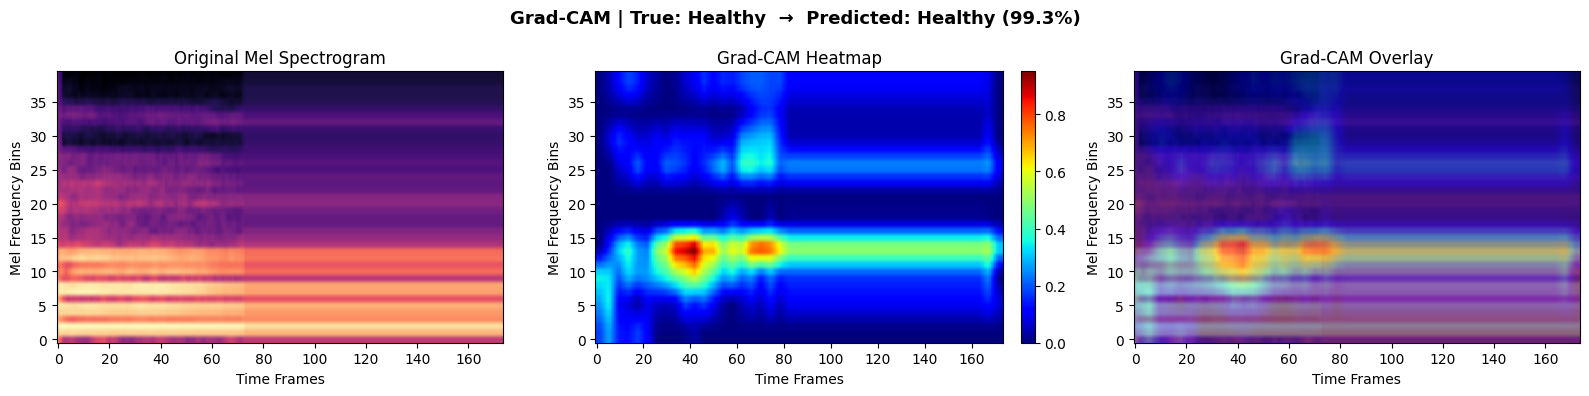

💾 Saved: gradcam_visualization.png

─── Interpretation ───────────────────────────────────────
🔴 Red/Yellow → High activation (CNN focuses HERE)
🔵 Blue       → Low activation (less relevant)
Y-axis        → Frequency (mel bins)
X-axis        → Time


In [ ]:
# CELL: Visualize — Side-by-Side Grad-CAM Overlay


spectrogram_2d  = sample[:, :, 0]                    # (H, W)
blended         = overlay_gradcam_on_spectrogram(spectrogram_2d, heatmap, alpha=0.45)

H, W            = spectrogram_2d.shape
heatmap_display = cv2.resize(heatmap, (W, H))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    f"Grad-CAM | True: {CLASS_NAMES[true_label]}  →  "
    f"Predicted: {CLASS_NAMES[pred_class]} ({pred_probs[pred_class]*100:.1f}%)",
    fontsize=13, fontweight='bold'
)

axes[0].imshow(spectrogram_2d, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title("Original Mel Spectrogram")
axes[0].set_xlabel("Time Frames")
axes[0].set_ylabel("Mel Frequency Bins")

im = axes[1].imshow(heatmap_display, aspect='auto', origin='lower', cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].set_xlabel("Time Frames")
axes[1].set_ylabel("Mel Frequency Bins")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(blended, aspect='auto', origin='lower')
axes[2].set_title("Grad-CAM Overlay")
axes[2].set_xlabel("Time Frames")
axes[2].set_ylabel("Mel Frequency Bins")

plt.tight_layout()
plt.savefig("gradcam_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: gradcam_visualization.png")
print("\n─── Interpretation ───────────────────────────────────────")
print(" Red/Yellow → High activation (CNN focuses HERE)")
print(" Blue       → Low activation (less relevant)")
print("Y-axis        → Frequency (mel bins)")
print("X-axis        → Time")

✅ Last Conv2D layer identified: 'conv2d_2'
✅ Last Conv2D layer identified: 'conv2d_2'
✅ Last Conv2D layer identified: 'conv2d_2'


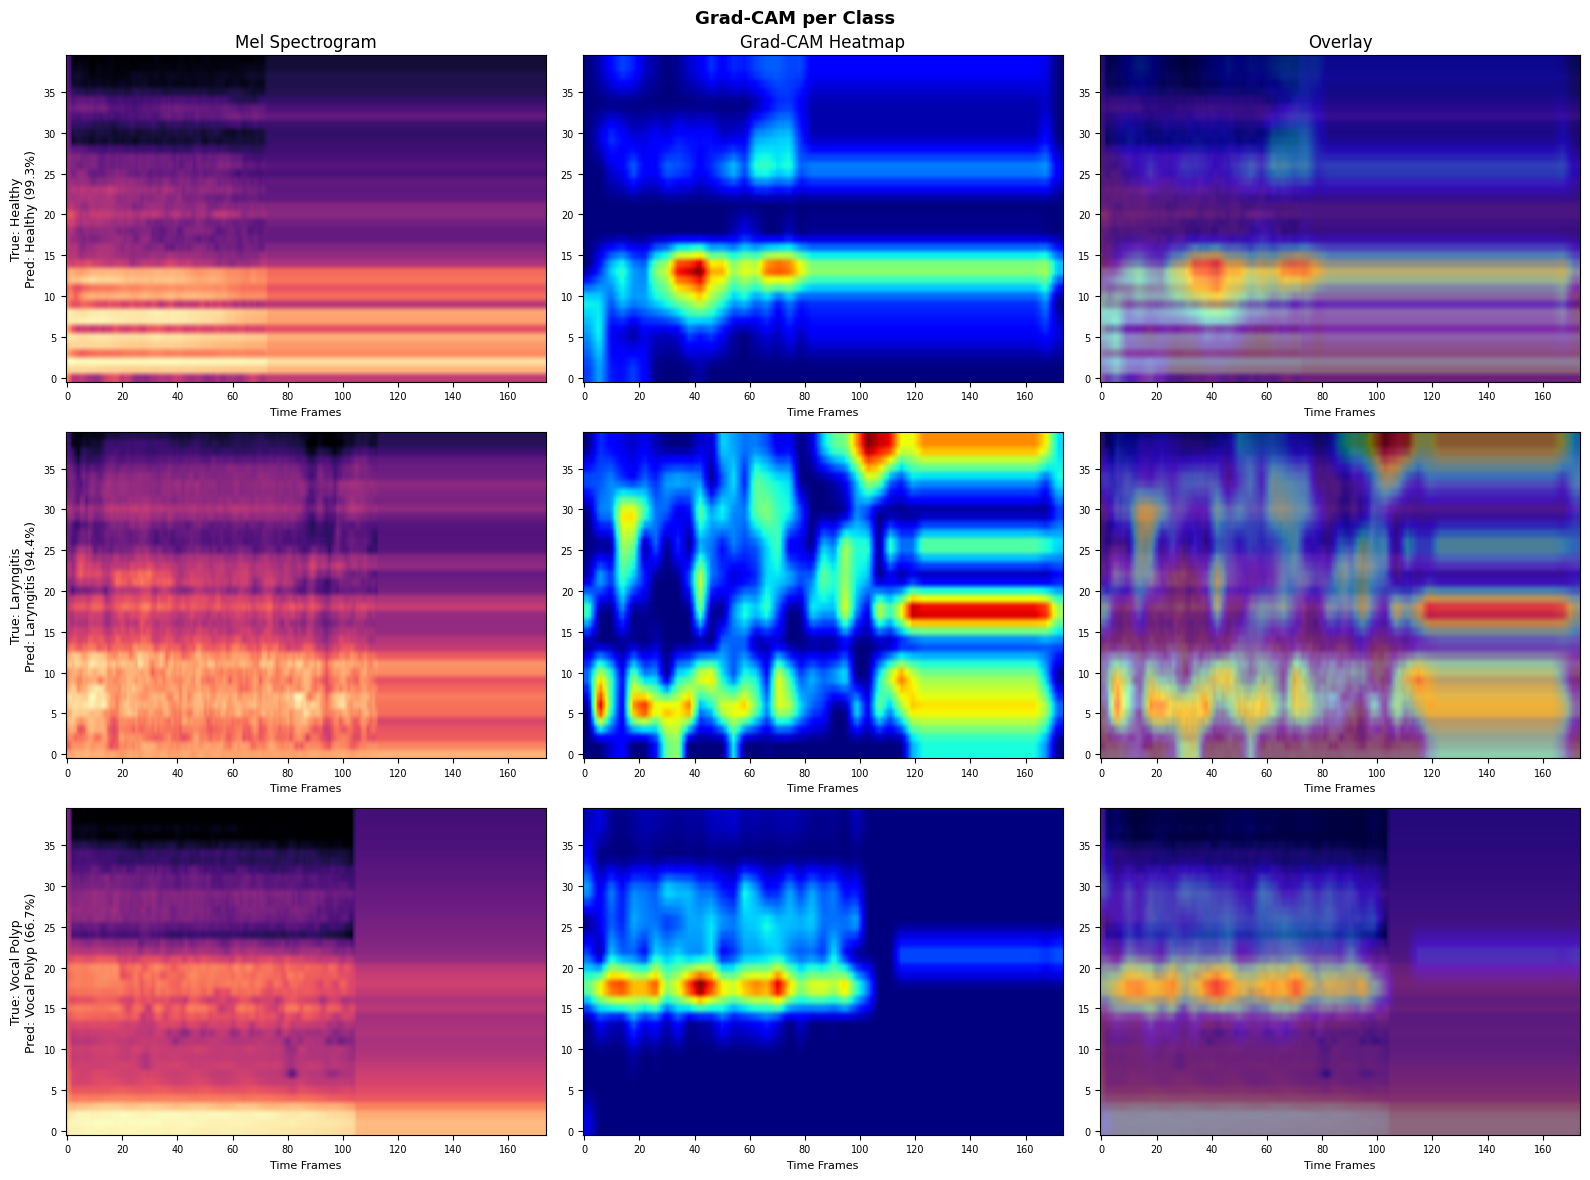

💾 Saved: gradcam_per_class.png


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL: (Optional) Multi-Sample Grad-CAM — One Per Class
# ─────────────────────────────────────────────────────────────────

num_classes = len(CLASS_NAMES)
fig, axes   = plt.subplots(num_classes, 3, figsize=(16, 4 * num_classes))
fig.suptitle("Grad-CAM per Class", fontsize=13, fontweight='bold')

for cls_idx in range(num_classes):
    cls_samples = np.where(y_test == cls_idx)[0]
    if len(cls_samples) == 0:
        print(f"⚠️  No test samples for class {CLASS_NAMES[cls_idx]}")
        continue

    idx    = cls_samples[0]
    samp   = X_test[idx]
    inp    = np.expand_dims(samp, axis=0)
    spec2d = samp[:, :, 0]

    hmap, pred_cls, probs = generate_gradcam(final_model, inp, class_index=None)
    blnd  = overlay_gradcam_on_spectrogram(spec2d, hmap, alpha=0.45)
    hdisp = cv2.resize(hmap, (spec2d.shape[1], spec2d.shape[0]))

    row_label = f"True: {CLASS_NAMES[cls_idx]}\nPred: {CLASS_NAMES[pred_cls]} ({probs[pred_cls]*100:.1f}%)"

    axes[cls_idx, 0].imshow(spec2d, aspect='auto', origin='lower', cmap='magma')
    axes[cls_idx, 0].set_ylabel(row_label, fontsize=9)
    if cls_idx == 0: axes[cls_idx, 0].set_title("Mel Spectrogram")

    axes[cls_idx, 1].imshow(hdisp, aspect='auto', origin='lower', cmap='jet')
    if cls_idx == 0: axes[cls_idx, 1].set_title("Grad-CAM Heatmap")

    axes[cls_idx, 2].imshow(blnd, aspect='auto', origin='lower')
    if cls_idx == 0: axes[cls_idx, 2].set_title("Overlay")

    for ax in axes[cls_idx]:
        ax.set_xlabel("Time Frames", fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("gradcam_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: gradcam_per_class.png")

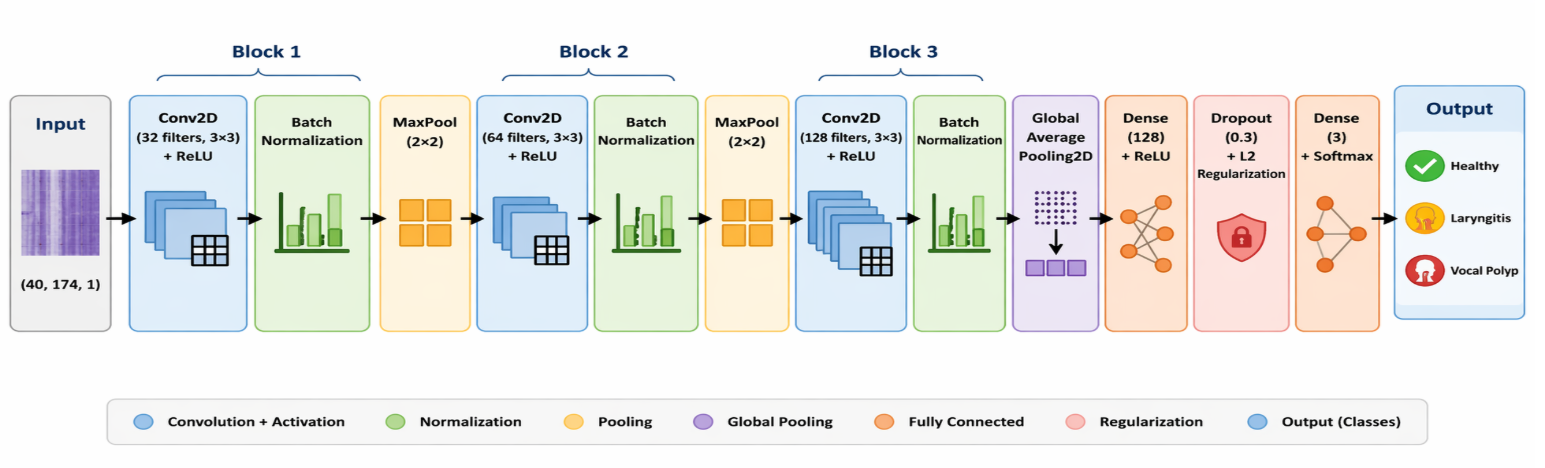

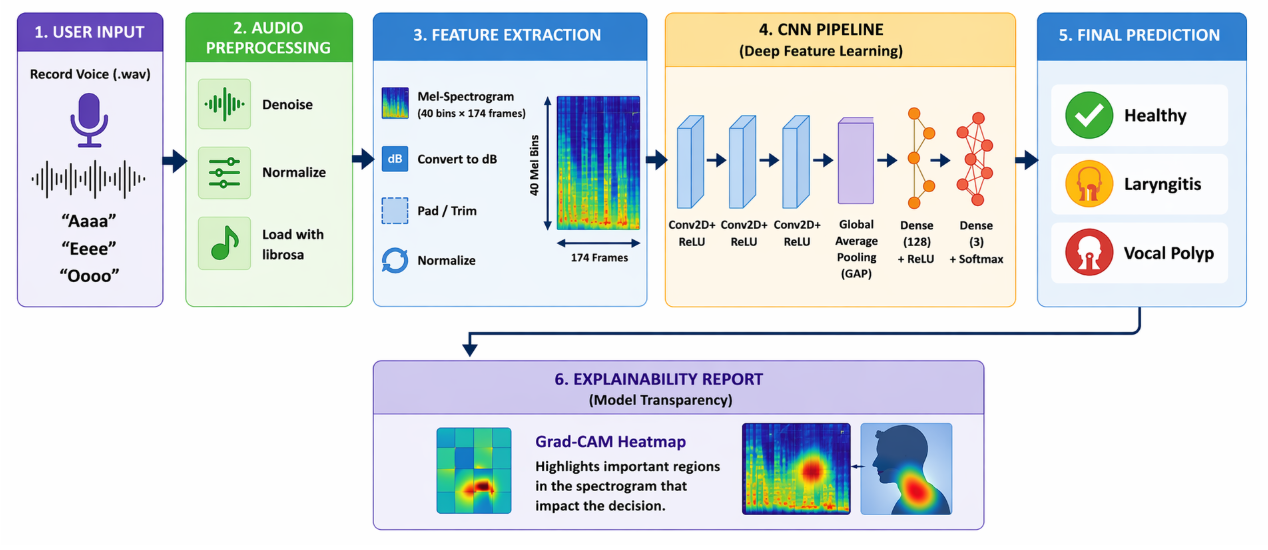